In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from pylab import *

In [2]:
def getAngle(a, b, c):
    """
    a: coordinate of p2
    b: coordinate of target
    c: coordinate of p1
    """
    ang = math.degrees(math.atan2(c[1]-b[1], c[0]-b[0]) - math.atan2(a[1]-b[1], a[0]-b[0]))
    if ang < 0:
        ang += 360
    return np.radians(ang)

In [3]:
def circle(p1, p2, angle):
    # End points of the chord
    x1, y1 = p1 
    x2, y2 = p2 

    # Point on the line perpendicular to the chord
    # Note that this line also passes through the center of the circle
    xm, ym = (x1+x2)/2, (y1+y2)/2

    # Distance between p1 and p2
    d_chord = np.sqrt((x1-x2)**2 + (y1-y2)**2)

    # Distance between xm, ym and center of the circle (xc, yc)
    d_perp = d_chord/(2*np.tan(angle/2))
    
    if y1==y2:
        xc = xm
        if x1 < x2:
            yc = ym - d_perp
        else:
            yc= ym + d_perp
    
    elif x1==x2:
        if y1 < y2:
            xc = xm + d_perp
        else:
            xc = xm - d_perp
        yc = ym

    else:
        # Slope of the line through the chord
        slope = (y1-y2)/(x1-x2)
        # Slope of a line perpendicular to the chord
        new_slope = -1/slope

        # Equation of line perpendicular to the chord: y-ym = new_slope(x-xm)
        # Distance between xm,ym and xc, yc: (yc-ym)^2 + (xc-xm)^2 = d_perp^2
        # Substituting from 1st to 2nd equation for y,
        #   we get: (new_slope^2+1)(xc-xm)^2 = d^2
        # Solve for xc:
        if np.sign(slope)==1:
            if x1 < x2:
                xc = d_perp/np.sqrt(new_slope**2+1) + xm
            else:
                xc = -d_perp/np.sqrt(new_slope**2+1) + xm
        else:
            if x1 < x2:
                xc = -d_perp/np.sqrt(new_slope**2+1) + xm
            else:
                xc = d_perp/np.sqrt(new_slope**2+1) + xm

        # Solve for yc:
        yc = (new_slope)*(xc-xm) + ym
    
    r = np.sqrt((xc-p1[0])**2 + (yc-p1[1])**2)

    return xc, yc, r

In [4]:
def intersection(xc1, yc1, r1, xc2, yc2, r2, xc3, yc3, r3):
    d = math.sqrt((xc2-xc1)**2 + (yc2-yc1)**2)
    
    # non intersecting
    if d > r1 + r2 :
        return None
    # One circle within other
    if d < abs(r1-r2):
        return None
    # coincident circles
    if d == 0 and r1 == r2:
        return None
    else:
        a=(r1**2-r2**2+d**2)/(2*d)
        h=math.sqrt(r1**2-a**2)
        
        x_2=xc1+a*(xc2-xc1)/d   
        y_2=yc1+a*(yc2-yc1)/d   
        
        x_3=x_2+h*(yc2-yc1)/d     
        y_3=y_2-h*(xc2-xc1)/d 

        x_4=x_2-h*(yc2-yc1)/d
        y_4=y_2+h*(xc2-xc1)/d
    
    # check satisfy equation of third circle
    if  round((x_3 - xc3)**2 + (y_3 - yc3)**2, 5) == round(r3**2, 5):
        return x_3, y_3
    
    else:
        return x_4, y_4

In [5]:
def test(p1, p2, p3, alpha, beta):
    xc1, yc1, r1 = circle(p1, p2, 2*alpha)
    xc2, yc2, r2 = circle(p2, p3, 2*beta)
    xc3, yc3, r3 = circle(p1, p3, 2 * (alpha + beta))

    cir1 = Circle((xc1,yc1), radius=r1,  color='green', fill=False)
    cir2 = Circle((xc2,yc2), radius=r2,  color='red', fill=False)
    cir3 = Circle((xc3,yc3), radius=r3,  color='blue', fill=False)
    gca().add_patch(cir1)
    gca().add_patch(cir2)
    gca().add_patch(cir3)

    plot(p1[0], p1[1], color='black', marker='o')
    plot(p2[0], p2[1], color='black', marker='o')
    plot(p3[0], p3[1], color='black', marker='o')
    plot(xc1, yc1, color='orange', marker='o')
    plot(xc2, yc2, color='orange', marker='o')
    plot(xc3, yc3, color='orange', marker='o')
    x_target, y_target = intersection(xc1, yc1, r1, xc2, yc2, r2, xc3, yc3, r3)
    print(x_target, y_target)
    plot(x_target, y_target, color='cyan', marker='o')
    
    plt.annotate("p1", (p1[0] + 0.1, p1[1] + 0.1))
    plt.annotate("p2", (p2[0] + 0.1, p2[1] + 0.1))
    plt.annotate("p3", (p3[0] + 0.1, p3[1] + 0.1))
    plt.annotate("target", (x_target + 0.1, y_target + 0.1))

    show()

## Assumptions:
1. The vehicle turns clockwise
2. The first torch sensed is p1, second is p2 last is p3
3. $\alpha$ is angle made by target with p1 and p2, $\beta$ is angle made by target with p2 and p3 <br>
Note: The order in which the first torch is sensed should not change results.

## Test case 1:
p1=(0, 0), p2=(1, $\sqrt{3}$), p3=(2, 0), $\alpha=\frac{2\pi}{3}$, $\beta=\frac{2\pi}{3}$

1.0 0.5773502691896254


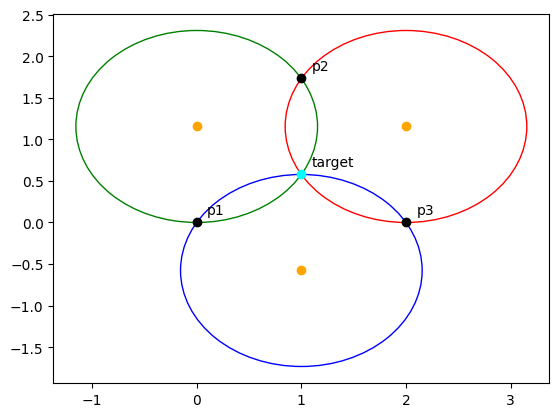

In [6]:
test([0, 0], [1, np.sqrt(3)], [2, 0], 2*np.pi/3, 2*np.pi/3)

p1=(1, $\sqrt{3}$), p2=(2, 0), p3=(0, 0), $\alpha=\frac{2\pi}{3}$, $\beta=\frac{2\pi}{3}$

0.9999999999999997 0.577350269189626


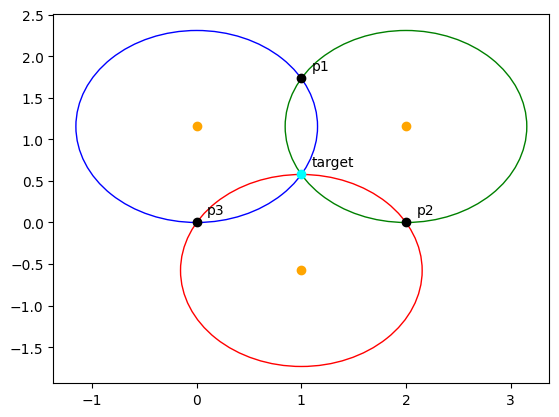

In [7]:
test([1, np.sqrt(3)], [2, 0], [0, 0], 2*np.pi/3, 2*np.pi/3)

p1=(2, 0), p2=(0, 0), p3=(1, $\sqrt{3}$), $\alpha=\frac{2\pi}{3}$, $\beta=\frac{2\pi}{3}$

1.0000000000000002 0.5773502691896262


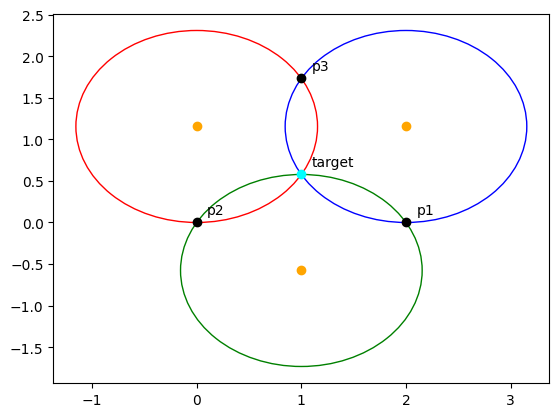

In [8]:
test([2, 0], [0, 0], [1, np.sqrt(3)], 2*np.pi/3, 2*np.pi/3)

## Test case 2:

1.3962472112780346 -1.490625042377896


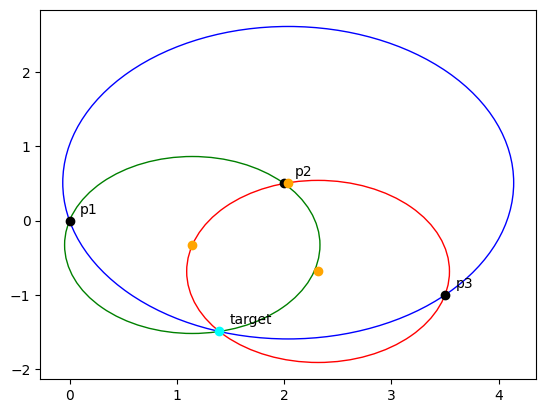

In [9]:
test([0, 0], [2, 0.5], [3.5, -1], np.pi/3, np.pi/3)

1.3962472112780329 -1.490625042377894


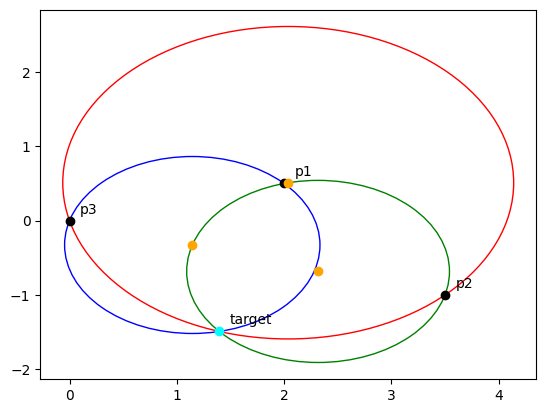

In [10]:
test([2, 0.5], [3.5, -1], [0, 0], np.pi/3, 4*np.pi/3)

1.3962472112780364 -1.490625042377895


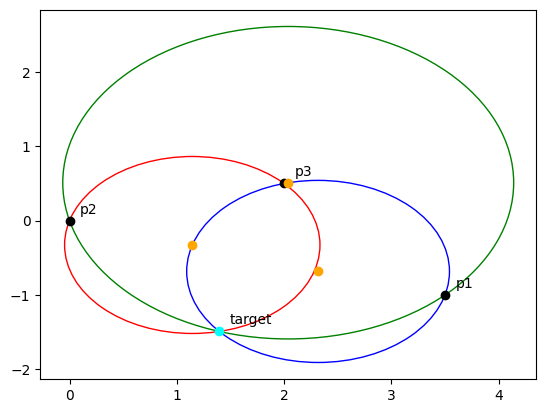

In [11]:
test([3.5, -1], [0, 0], [2, 0.5], 4*np.pi/3, np.pi/3)

## Test case 3:

-0.5773502691896257 1.0


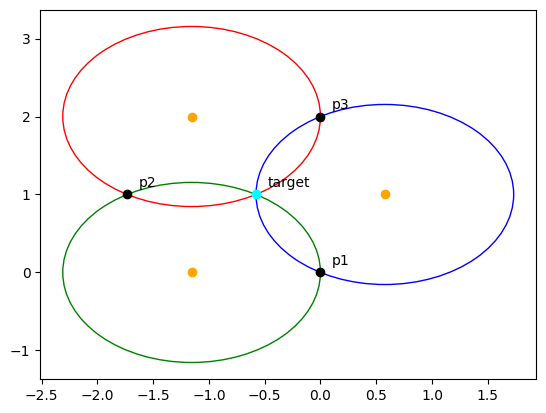

In [12]:
test([0, 0], [-np.sqrt(3), 1], [0, 2], 2*np.pi/3, 2*np.pi/3)

-0.5773502691896262 0.9999999999999998


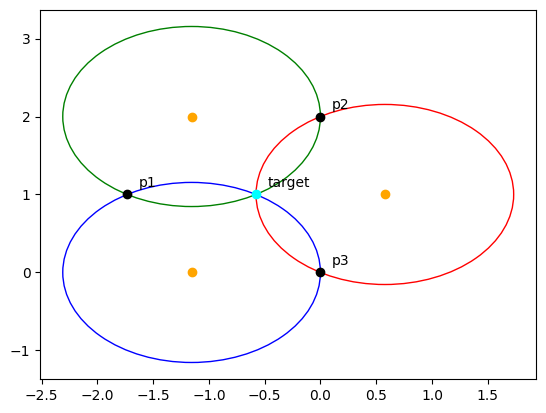

In [13]:
test([-np.sqrt(3), 1], [0, 2], [0,0], 2*np.pi/3, 2*np.pi/3)

-0.577350269189626 1.0000000000000002


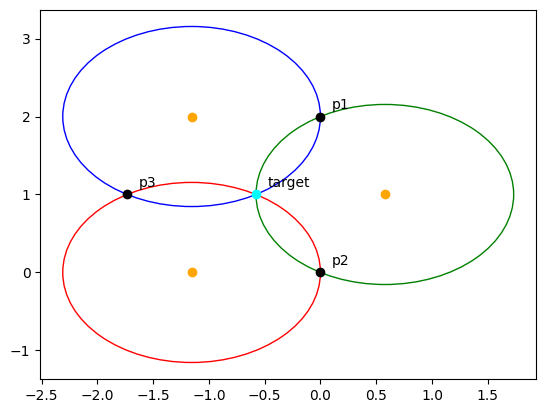

In [14]:
test([0, 2], [0,0], [-np.sqrt(3), 1], 2*np.pi/3, 2*np.pi/3)

## Test case 4:

0.7500000000000149 -2.0000000000000084


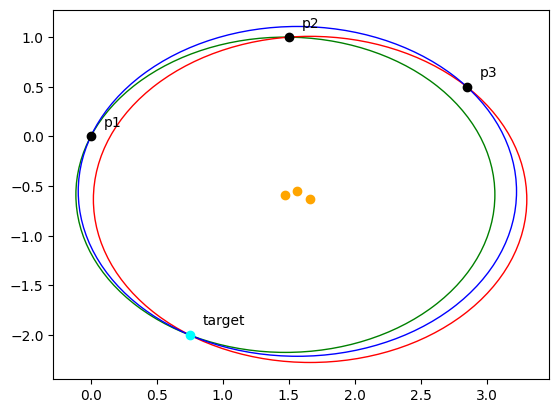

In [15]:
p1 = [0, 0]
p2 = [1.5, 1]
p3 = [2.85, 0.5]
target = [0.75, -2]
alpha = getAngle(p2, target, p1)
beta = getAngle(p3, target, p2)
test(p1, p2, p3, alpha, beta)

0.7500000000000058 -2.0000000000000027


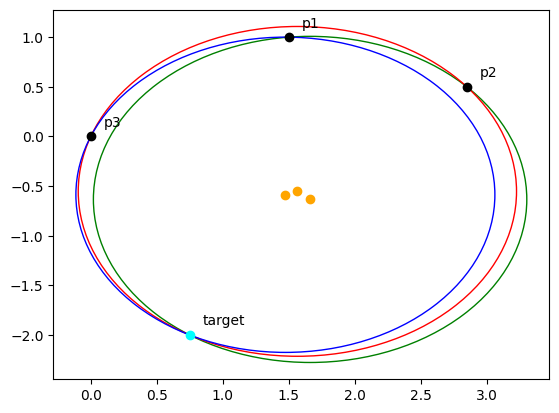

In [16]:
p1 = [1.5, 1]
p2 = [2.85, 0.5]
p3 = [0, 0]
target = [0.75, -2]
alpha = getAngle(p2, target, p1)
beta = getAngle(p3, target, p2)
test(p1, p2, p3, alpha, beta)

0.750000000000034 -2.000000000000018


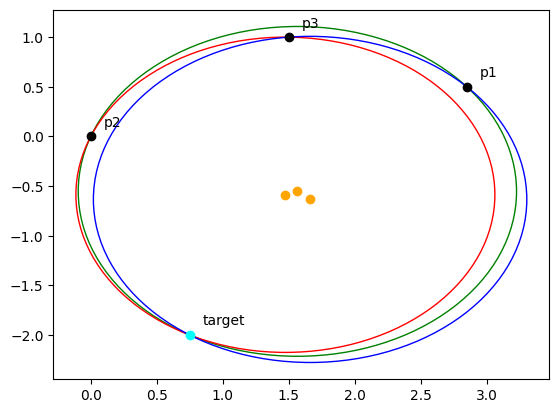

In [17]:
p1 = [2.85, 0.5]
p2 = [0, 0]
p3 = [1.5, 1]
target = [0.75, -2]
alpha = getAngle(p2, target, p1)
beta = getAngle(p3, target, p2)
test(p1, p2, p3, alpha, beta)

5.9986218753528 5.001487207257506


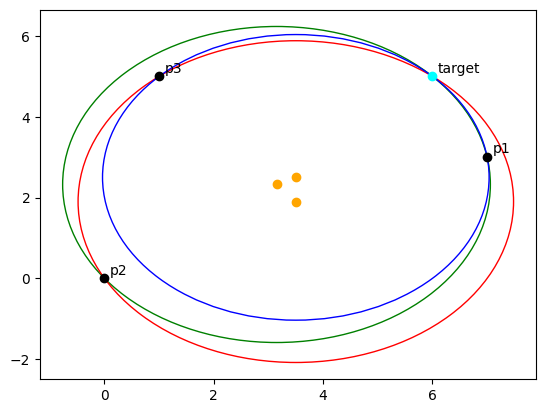

In [23]:
## Test case 5:
test([7, 3], [0, 0], [1, 5], 1.3397, 0.6947)

5.999986841214708 3.999995862397666


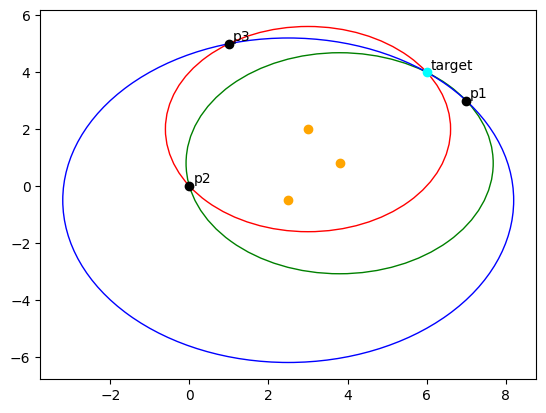

In [24]:
## Test case 6:
test([7, 3], [0, 0], [1, 5], 1.7682, 0.7854)

5.020403000323596 3.004553101129428


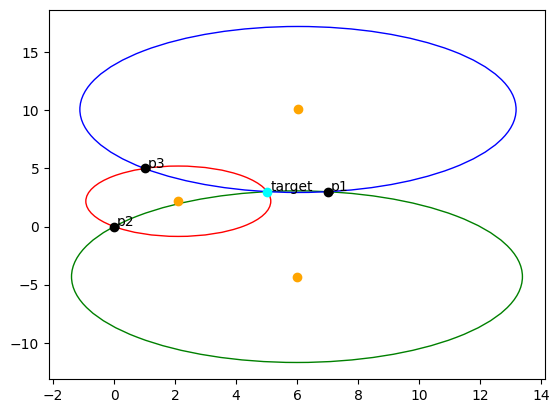

In [26]:
## Test case 7:
test([7, 3], [0, 0], [1, 5], 2.60, 1.00)

-0.025927833536135036 2.9437118665832345


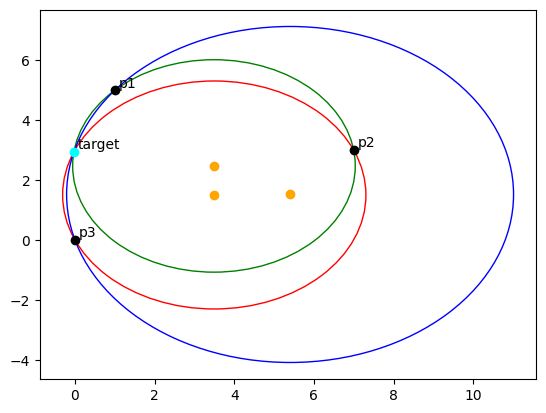

In [28]:
## Test case 8:
test([1, 5], [7, 3], [0, 0], 1.10, 1.57)